# Lecture 2: Spiral classification


In [ ]:
import numpy as np
import torch
import torch.nn as nn
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
# Plot functions
import matplotlib.pyplot as plt
from IPython import display
plt.rc('figure', figsize=(8, 8))

def plot_data(X, y, d=0, auto=False, zoom=1):
    X = X.cpu()
    y = y.cpu()
    plt.scatter(X.numpy()[:, 0], X.numpy()[:, 1], c=y)
    plt.axis('square')
    plt.axis(np.array((-1.1, 1.1, -1.1, 1.1)) * zoom)
    if auto is True: plt.axis('equal')
    plt.axis('off')

def plot_model(X, y, model):
    model.cpu()

    mesh = np.arange(-1.1, 1.1, 0.01)
    xx, yy = np.meshgrid(mesh, mesh)
    with torch.no_grad():
        data = torch.from_numpy(np.vstack((xx.reshape(-1), yy.reshape(-1))).T).float()
        Z = model(data).detach()
    Z = np.argmax(Z, axis=1).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plot_data(X, y)

In [ ]:
# Setup
seed = 12345
torch.manual_seed(seed)

N = 100  # num_samples_per_class
D = 2    # dimensions
C = 2    # num_classes
H = 10  # num_hidden_units

In [ ]:
# Generate spiral data
X = torch.zeros(N * C, D).to(device)
y = torch.zeros(N * C, dtype=torch.long).to(device)
# y = torch.zeros(N * C, dtype=torch.float32).to(device)

for c in range(C):
    index = 0
    t = torch.linspace(0, 1, N)
    # When c = 0 and t = 0: start of linspace
    # When c = 0 and t = 1: end of linpace
    # This inner_var is for the formula inside sin() and cos() like sin(inner_var) and cos(inner_Var)
    inner_var = torch.linspace(
        # When t = 0
        (2 * np.pi / C) * (c),
        # When t = 1
        (2 * np.pi / C) * (2 + c),
        N
    ) + torch.randn(N) * 0.2

    for ix in range(N * c, N * (c + 1)):
        X[ix] = t[index] * torch.FloatTensor((
            np.sin(inner_var[index]), np.cos(inner_var[index])
        ))
        y[ix] = c
        index += 1

/tmp/ipython-input-3306280452.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.sin(inner_var[index]), np.cos(inner_var[index])


In [ ]:
print(X, y)

tensor([[-0.0000,  0.0000],
        [ 0.0016,  0.0100],
        [-0.0093,  0.0180],
        [ 0.0084,  0.0291],
        [ 0.0129,  0.0383],
        [ 0.0156,  0.0480],
        [ 0.0250,  0.0552],
        [ 0.0132,  0.0695],
        [ 0.0676,  0.0443],
        [ 0.0750,  0.0513],
        [ 0.0719,  0.0710],
        [ 0.0527,  0.0978],
        [ 0.0799,  0.0912],
        [ 0.1068,  0.0763],
        [ 0.1244,  0.0673],
        [ 0.1266,  0.0832],
        [ 0.1511,  0.0575],
        [ 0.1292,  0.1131],
        [ 0.1654,  0.0755],
        [ 0.1909,  0.0194],
        [ 0.1769,  0.0976],
        [ 0.1995,  0.0721],
        [ 0.2214,  0.0196],
        [ 0.2043,  0.1106],
        [ 0.2372, -0.0499],
        [ 0.2470,  0.0528],
        [ 0.2543, -0.0657],
        [ 0.2618, -0.0765],
        [ 0.2742, -0.0693],
        [ 0.2919, -0.0245],
        [ 0.2840, -0.1056],
        [ 0.2984, -0.0948],
        [ 0.3098, -0.0923],
        [ 0.3125, -0.1160],
        [ 0.3001, -0.1670],
        [ 0.2920, -0

In [ ]:
X.shape, y.shape

(torch.Size([200, 2]), torch.Size([200]))

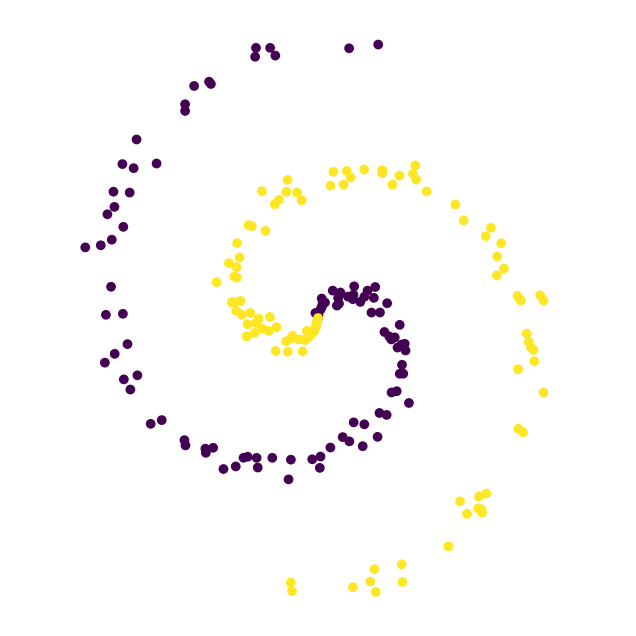

In [ ]:
plot_data(X, y)

### Linear model

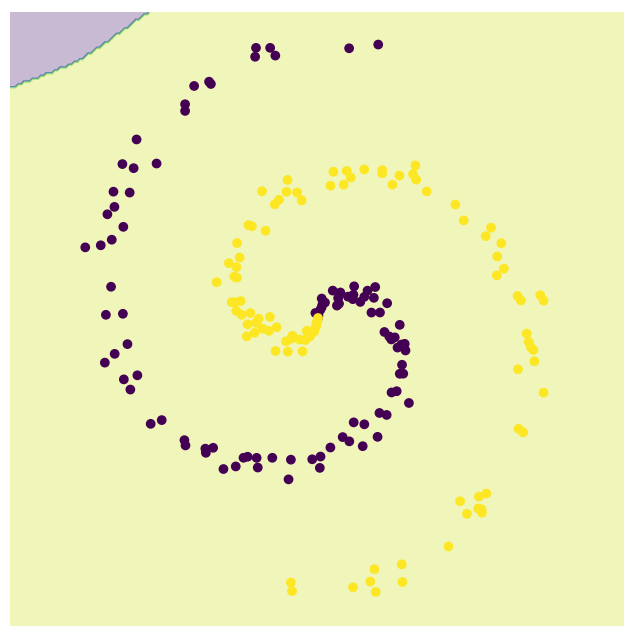

In [ ]:
# we use the torch.nn package to create our linear model
# each Linear module has a weight and bias

H1 = 100
H2 = 15


# perceptron
model = torch.nn.Sequential(
    torch.nn.Linear(D, C),
    torch.nn.Softmax()
)

# model = torch.nn.Sequential(
#     #torch.nn.Linear(D, C)
#     torch.nn.Linear(D, H1),
#     torch.nn.ReLU(),
#     # torch.nn.Linear(H1, H2),
#     # torch.nn.ReLU(),
#     torch.nn.Linear(H1,C),
#     torch.nn.Softmax()
# )

# Convert to CUDA
model.to(device)

# torhc.nn package also has different loss functions.
# we use cross entropy loss for our classification task
criterion = torch.nn.CrossEntropyLoss()
# criterion = torch.nn.BCELoss()

# we use the optim package to apply
# stochastic gradient descent for our parameter updates
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Training
for t in range(2000):
    # Feed forward to get the logits
    y_pred = model(X)
    y_pred = y_pred.squeeze()
    # print(y.shape, y_pred.shape)
    # Compute the loss and accuracy
    loss = criterion(y_pred, y)
    score, predicted = torch.max(y_pred, 1)
    # predicted = (y_pred > 0.5).float()
    acc = (y == predicted).sum().float() / len(y)

    if t % 25 == 0:
        plt.clf()
        plot_model(X, y, model)
        model.to(device)
        display.display(plt.gcf())
        print("[EPOCH]: %i, [LOSS]: %.6f, [ACCURACY]: %.3f" % (t, loss.item(), acc))
        display.clear_output(wait=True)

    # print("[EPOCH]: , [LOSS]: %.6f, [ACCURACY]: %.3f" % (loss.item(), acc))
    # zero the gradients before running
    # the backward pass.
    optimizer.zero_grad()

    # Backward pass to compute the gradient
    # of loss w.r.t our learnable params.
    loss.backward()

    # Update params
    # optimizer.step()

### MLP

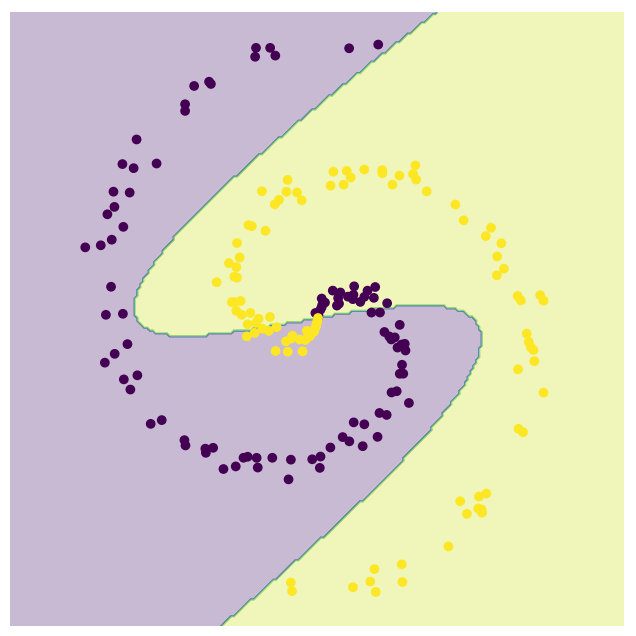

In [ ]:
# nn package to create our linear model
# each Linear module has a weight and bias

H = 100

# perceptron
# model = torch.nn.Sequential(
#     torch.nn.Linear(D, C),
#     torch.nn.Softmax()
# )

model = torch.nn.Sequential(
    torch.nn.Linear(D, H),
    # torch.nn.Sigmoid(),
    torch.nn.ReLU(),
    torch.nn.Linear(H, H),
    # #torch.nn.Sigmoid(),
    torch.nn.ReLU(),
    torch.nn.Linear(H, C),
    torch.nn.Softmax()
)



# model = torch.nn.Sequential(
#     torch.nn.Linear(D, H),
#     torch.nn.Sigmoid(),
#     torch.nn.Linear(H, H),
#     torch.nn.Sigmoid(),
#     torch.nn.Linear(H, H),
#     torch.nn.Sigmoid(),
#     torch.nn.Linear(H, H),
#     torch.nn.Sigmoid(),
#     torch.nn.Linear(H, C)
# )

model.to(device)

# nn package also has different loss functions.
# we use cross entropy loss for our classification task
criterion = torch.nn.CrossEntropyLoss()

# we use the optim package to apply
# ADAM for our parameter updates
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Training
for t in range(2000):
    # Feed forward to get the logits
    y_pred = model(X)

    # Compute the loss and accuracy
    loss = criterion(y_pred, y)
    score, predicted = torch.max(y_pred, 1)
    acc = (y == predicted).sum().float() / len(y)

    if t % 25 == 0:
        plt.clf()
        plot_model(X, y, model)
        model.to(device)
        display.display(plt.gcf())
        print("[EPOCH]: %i, [LOSS]: %.6f, [ACCURACY]: %.3f" % (t, loss.item(), acc))
        display.clear_output(wait=True)

    # zero the gradients before running
    # the backward pass.
    optimizer.zero_grad()

    # Backward pass to compute the gradient
    # of loss w.r.t our learnable params.
    loss.backward()

    # Update params
    optimizer.step()

In [ ]:
x = torch.randn(3, requires_grad=True)
y = x + 2
z = y.mean()

# Compute gradients
z.backward()
print(x.grad)


tensor([0.3333, 0.3333, 0.3333])


In [ ]:
# model.eval()  # Set the model to evaluation mode
# with torch.no_grad():
#     test_data = torch.tensor([[-0.2513, -0.4955]])
#     prediction = model(test_data)
#     print(prediction)
#     # Apply threshold to convert continuous output to binary (0 or 1)
#     # binary_prediction = (prediction >= 0.5).float()  # Converts to 0 or 1 based on threshold
#     # print(f"Prediction for input [1.0, 1.0]: {binary_prediction.item()}")